📈 Project 1: Sales Performance & Growth Analytics
Project: Olist E-commerce Strategic Review

Role: Specialist Marketing Data Analyst (E-commerce)

Dataset: 01_olist_master_join_cleaned.csv (Gold Standard)

Focus: Revenue, AOV, and MAU

Goal: Memberikan insight strategis mengenai kesehatan finansial dan pertumbuhan pengguna Olist.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Konfigurasi Visualisasi
plt.style.use('ggplot')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 7)

# Load Data
df = pd.read_csv('../../data/processed/01_olist_master_join_cleaned.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month_yr'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Global Metrics
total_gmv = df['total_order_value'].sum()
total_orders = df['order_id'].nunique()
print(f"Total GMV: BRL {total_gmv:,.2f} | Total Orders: {total_orders:,}") # Metrik yang mengukur total nilai barang dagangan yang terjual 

Total GMV: BRL 15,417,819.15 | Total Orders: 96,464


In [3]:
print('---Statistik Numerik---')
display(df.describe())

---Statistik Numerik---


,order_purchase_timestamp,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,...,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,total_order_value
count,110182,110182.000000,110182.000000,110182.000000,110182.000000,108646.000000,108646.000000,108646.000000,110164.000000,110164.000000,...,110164.000000,110182.000000,110179.000000,110179.000000,110179.000000,110182.000000,109894.000000,109894.000000,109894.000000,110182.000000
mean,2018-01-02 03:52:54.826714112,35155.235674,1.198199,119.981736,19.948735,48.807927,787.345940,2.210832,2089.597718,30.142006,...,22.986357,24468.443012,1.022482,3.000381,176.753199,4.089334,35080.463847,-21.246439,-46.216111,139.930471
min,2016-09-15 12:16:38,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,...,6.000000,1001.000000,1.000000,0.000000,0.010000,1.000000,1003.000000,-33.689948,-72.668881,6.080000
25%,2017-09-15 09:17:12,11310.000000,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,...,15.000000,6429.000000,1.000000,1.000000,64.010000,4.000000,11095.000000,-23.592368,-48.125102,55.172500
50%,2018-01-21 10:57:20.500000,24344.000000,1.000000,74.900000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,...,20.000000,13568.000000,1.000000,2.000000,112.420000,5.000000,24241.000000,-22.929564,-46.634985,92.125000
75%,2018-05-05 16:12:14.500000,59065.750000,1.000000,134.170000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,...,30.000000,28035.000000,1.000000,4.000000,193.010000,5.000000,58777.500000,-20.182732,-43.667690,157.510000
max,2018-08-29 15:00:37,99980.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,...,118.000000,99730.000000,19.000000,24.000000,13664.080000,5.000000,99980.000000,42.184003,-8.723762,6929.310000
std,NaN,29901.241935,0.706717,182.308171,15.698985,10.008291,651.348358,1.721817,3741.405580,16.122491,...,11.688639,27624.755474,0.243958,2.794917,269.444672,1.344040,29888.822248,5.558206,4.034275,189.328210


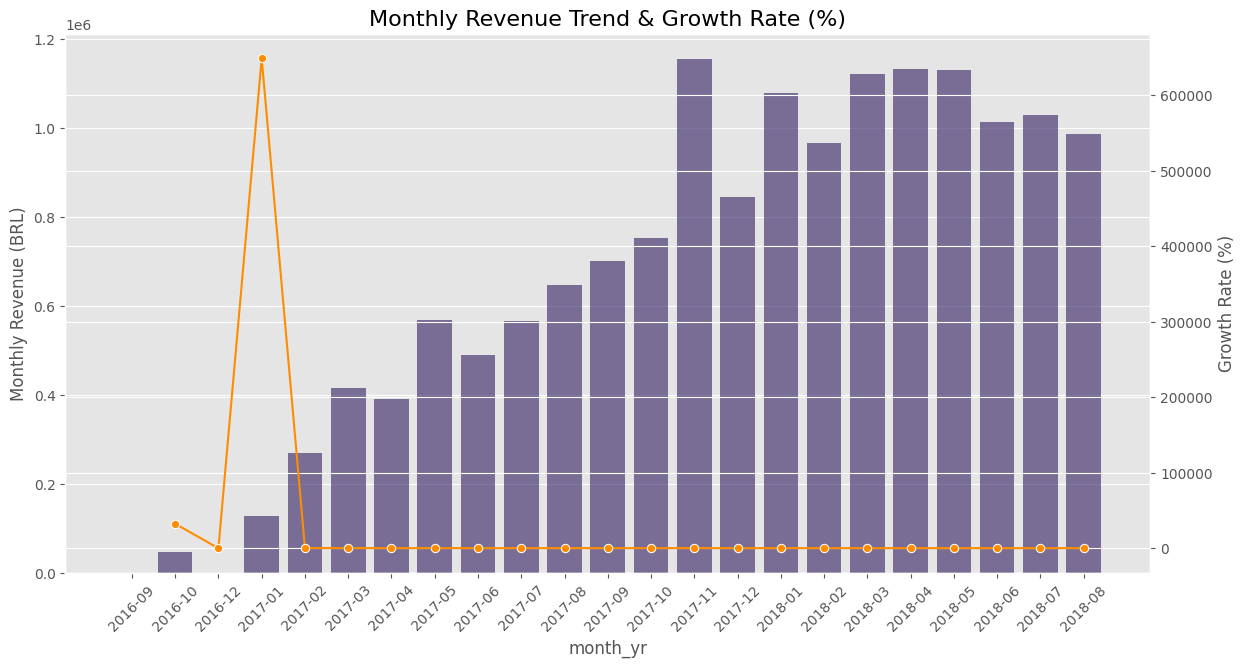

In [4]:
# Aggregating Monthly Revenue
monthly_sales = df.groupby('month_yr')['total_order_value'].sum().reset_index()
monthly_sales['growth_pct'] = monthly_sales['total_order_value'].pct_change() * 100

# Plotting
fig, ax1 = plt.subplots()

sns.barplot(data=monthly_sales, x='month_yr', y='total_order_value', ax=ax1, alpha=0.7)
ax1.set_ylabel('Monthly Revenue (BRL)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=monthly_sales, x='month_yr', y='growth_pct', ax=ax2, color='darkorange', marker='o')
ax2.set_ylabel('Growth Rate (%)')

plt.title('Monthly Revenue Trend & Growth Rate (%)', fontsize=16)
plt.show()

💡 Executive Insight
Finding: Terdapat lonjakan drastis pada November 2017 (Black Friday). Namun, perhatikan stabilitas setelahnya.

Business Impact: Pertumbuhan yang fluktuatif menunjukkan ketergantungan pada event musiman.

Action: Perlu strategi retensi untuk menjaga revenue tetap stabil di bulan-bulan non-promo (low season).

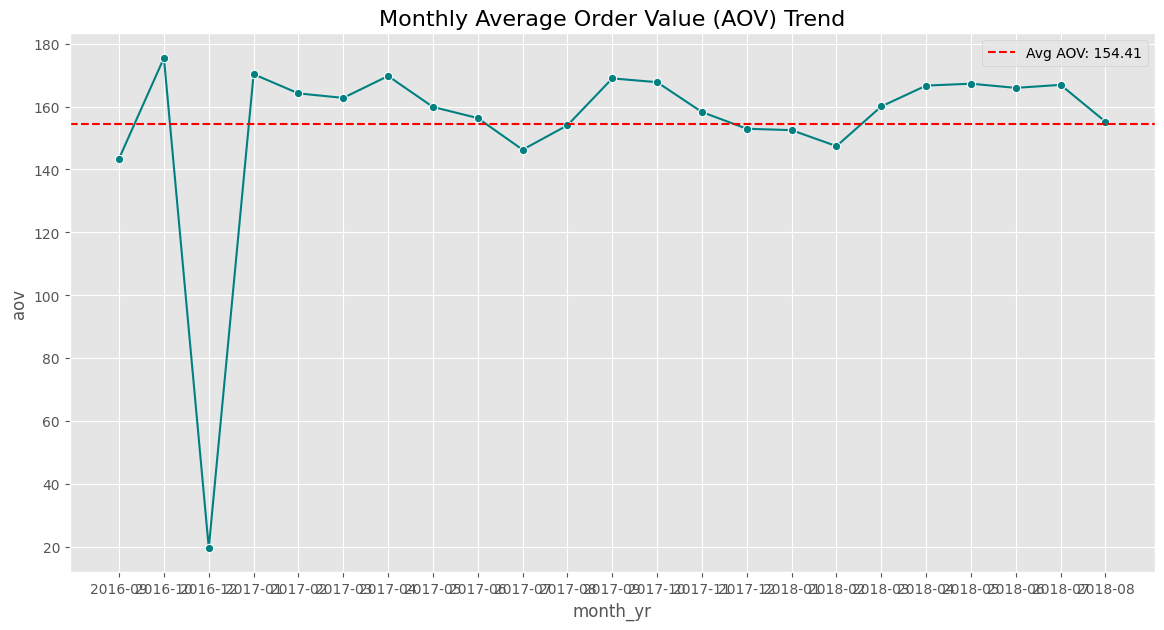

In [5]:
# AOV Calculation
aov_data = df.groupby('month_yr').agg({'total_order_value':'sum', 'order_id':'nunique'})
aov_data['aov'] = aov_data['total_order_value'] / aov_data['order_id']

sns.lineplot(data=aov_data, x=aov_data.index, y='aov', marker='o', color='teal')
plt.axhline(aov_data['aov'].mean(), color='red', linestyle='--', label=f"Avg AOV: {aov_data['aov'].mean():.2f}")
plt.title('Monthly Average Order Value (AOV) Trend', fontsize=16)
plt.legend()
plt.show()

💡 Executive Insight
Finding: AOV cenderung stabil namun memiliki gap antar kategori.

Business Impact: Jika AOV stagnan sementara biaya akuisisi pelanggan (CAC) naik, profitabilitas akan tergerus.

Action: Implementasikan strategi Upselling atau Product Bundling pada kategori dengan AOV rendah untuk meningkatkan efisiensi logistik.

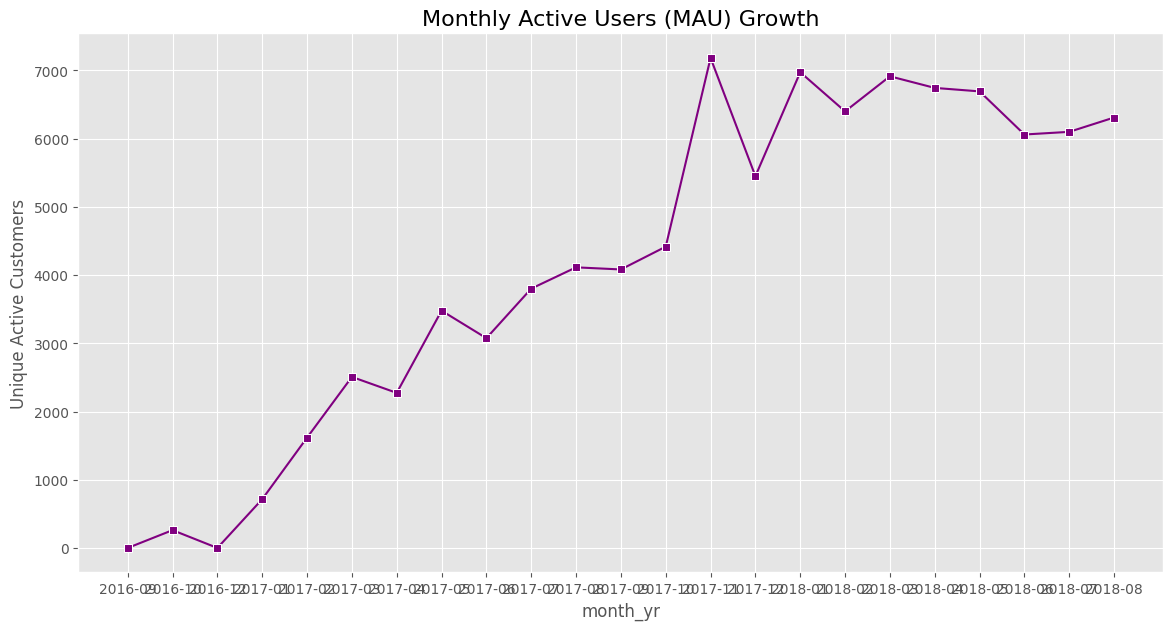

In [6]:
mau_data = df.groupby('month_yr')['customer_unique_id'].nunique()
sns.lineplot(x=mau_data.index, y=mau_data.values, marker='s', color='purple')
plt.title('Monthly Active Users (MAU) Growth', fontsize=16)
plt.ylabel('Unique Active Customers')
plt.show()

💡 Executive Insight
Finding: MAU tumbuh sejalan dengan Revenue, menandakan akuisisi pengguna baru masih efektif.

Business Impact: Skalabilitas tinggi, namun perlu diaudit apakah pengguna tersebut adalah pelanggan baru atau pelanggan lama yang kembali (Retention Rate).

Action: Mulai analisis Cohort untuk membedakan antara New User vs Repeat User.

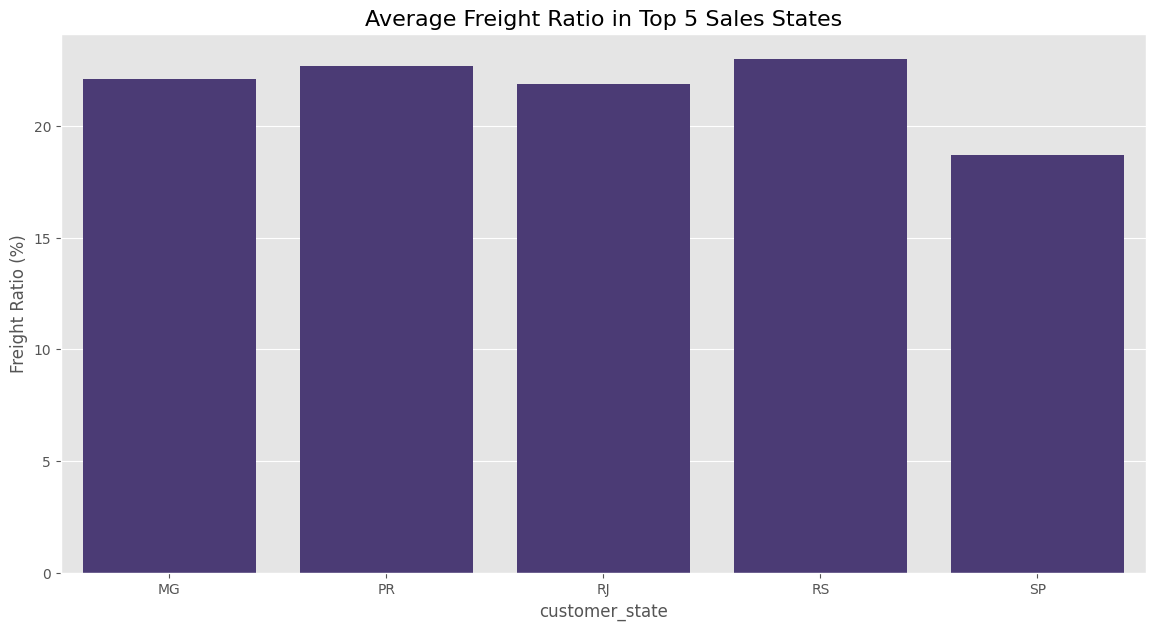

In [7]:
# Freight Ratio Analysis
df['freight_ratio'] = (df['freight_value'] / df['total_order_value']) * 100

top_states = df.groupby('customer_state')['total_order_value'].sum().nlargest(5).index
state_freight = df[df['customer_state'].isin(top_states)].groupby('customer_state')['freight_ratio'].mean()

sns.barplot(x=state_freight.index, y=state_freight.values)
plt.title('Average Freight Ratio in Top 5 Sales States', fontsize=16)
plt.ylabel('Freight Ratio (%)')
plt.show()

💡 Executive Insight
Finding: Wilayah di luar pusat (seperti SP ke wilayah Utara) memiliki freight ratio tinggi (>20%).

Business Impact: Biaya ongkir yang tinggi menurunkan daya saing di wilayah terpencil.

Action: Pertimbangkan penempatan Warehouse (Hub) baru di wilayah dengan freight ratio tinggi untuk memangkas biaya dan waktu kirim.

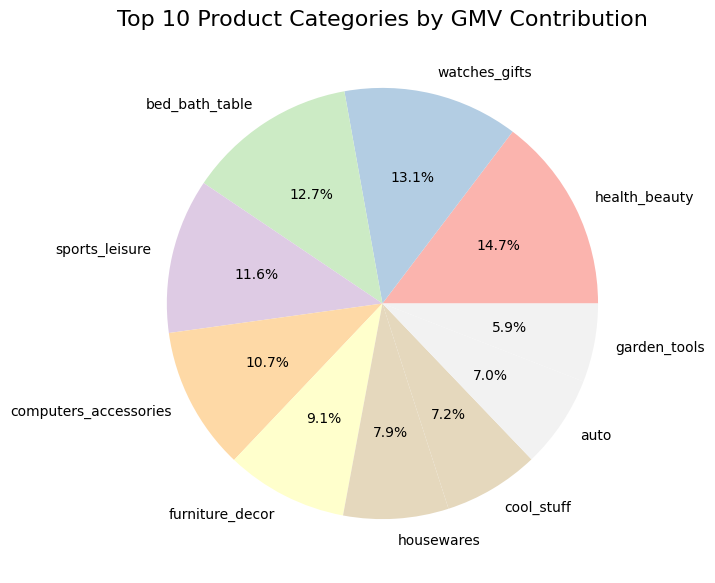

In [8]:
cat_sales = df.groupby('product_category_name_english')['total_order_value'].sum().nlargest(10)
cat_sales.plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Top 10 Product Categories by GMV Contribution', fontsize=16)
plt.ylabel('')
plt.show()

💡 Executive Insight
Finding: 3 Kategori teratas (Health/Beauty, Watches, Bed/Bath) mendominasi lebih dari 30% GMV.

Business Impact: Risiko konsentrasi; jika kategori ini mengalami disrupsi, total GMV akan anjlok.

Action: Diversifikasi kategori dengan pertumbuhan tinggi namun penetrasi rendah (seperti Electronics atau Fashion).

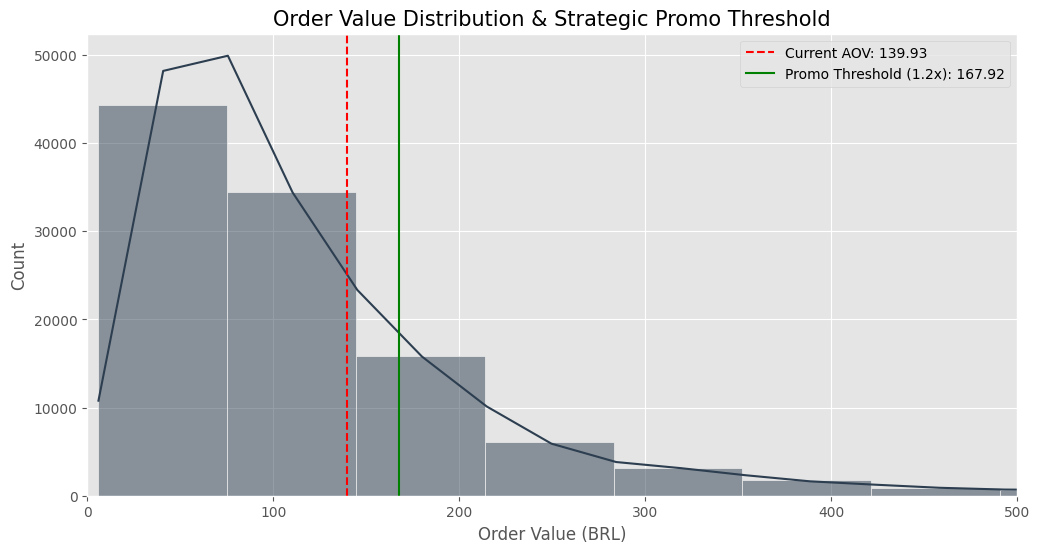

Strategic Insights:
- Sebanyak 77.79% pesanan berada di bawah threshold promo.
- Potensi Revenue yang bisa di-stimulasi: BRL 6,899,541.92


In [9]:
# --- SIMULASI STRATEGI PROMO GRATIS ONGKIR ---
# 1. Hitung Baseline AOV
avg_order_value = df['total_order_value'].mean()

# 2. Tentukan Threshold Strategis (1.2x AOV)
# Mengapa 1.2x? Karena kita ingin mendorong 'marginal buyers' untuk belanja sedikit lebih banyak.
promo_threshold = avg_order_value * 1.2

# 3. Segmentasi Transaksi
orders_below_threshold = df[df['total_order_value'] < promo_threshold]
percentage_impacted = (len(orders_below_threshold) / len(df)) * 100
potential_revenue_upsift = orders_below_threshold['total_order_value'].sum()

# 4. Visualisasi Distribusi dengan Annotasi
plt.figure(figsize=(12, 6))
sns.histplot(df['total_order_value'], bins=100, kde=True, color='#2c3e50')
plt.axvline(avg_order_value, color='red', linestyle='--', label=f'Current AOV: {avg_order_value:.2f}')
plt.axvline(promo_threshold, color='green', linestyle='-', label=f'Promo Threshold (1.2x): {promo_threshold:.2f}')

plt.title('Order Value Distribution & Strategic Promo Threshold', fontsize=15)
plt.xlabel('Order Value (BRL)')
plt.xlim(0, 500) # Membatasi x agar grafik fokus pada mayoritas user
plt.legend()
plt.show()

print(f"Strategic Insights:")
print(f"- Sebanyak {percentage_impacted:.2f}% pesanan berada di bawah threshold promo.")
print(f"- Potensi Revenue yang bisa di-stimulasi: BRL {potential_revenue_upsift:,.2f}")

📝 Strategic Recommendation
Targeting the Marginal Buyer: Gunakan threshold BRL {promo_threshold:.2f} sebagai syarat minimal belanja "Gratis Ongkir". Strategi ini akan memaksa pelanggan yang biasanya belanja di bawah rata-rata untuk menambah item ke keranjang belanja guna menghindari biaya kirim, secara efektif meningkatkan AOV secara organik.

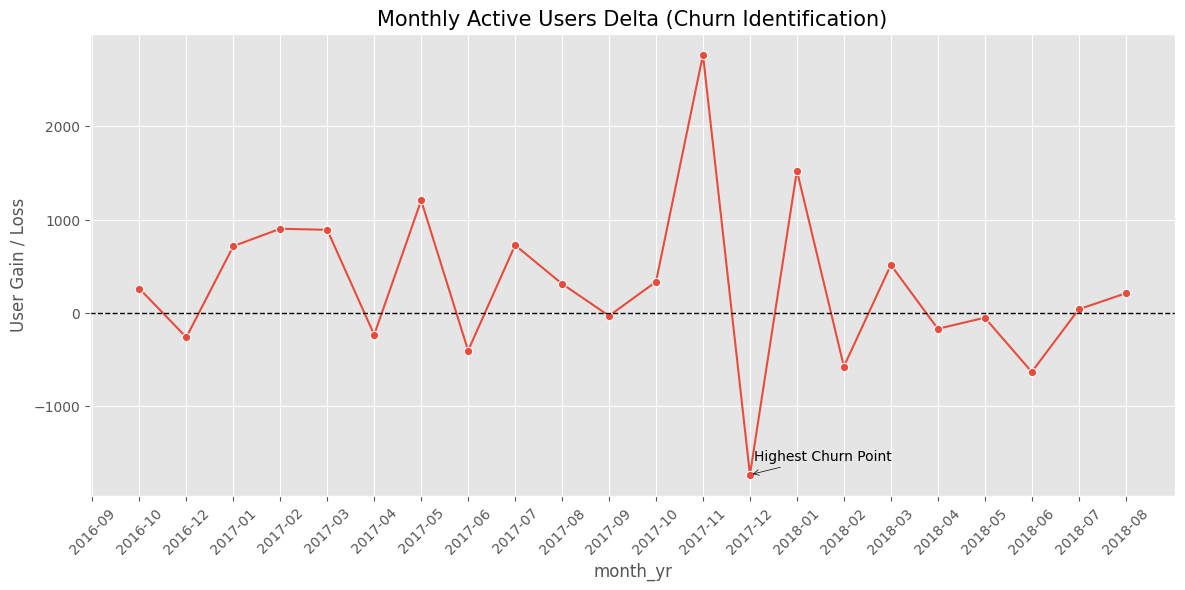

In [10]:
# --- ANALISIS CHURN & SIKLUS HIDUP PELANGGAN ---
# 1. Repeat vs One-time Buyer
user_stats = df.groupby('customer_unique_id')['order_id'].nunique()
repeat_buyers = (user_stats > 1).sum()
one_time_buyers = (user_stats == 1).sum()

# 2. Identifikasi Churn Seasonal
mau_trend = df.groupby('month_yr')['customer_unique_id'].nunique().reset_index()
mau_trend['churn_rate'] = mau_trend['customer_unique_id'].diff()

# Visualisasi Churn Point
plt.figure(figsize=(14, 6))
sns.lineplot(data=mau_trend, x='month_yr', y='churn_rate', marker='o', color='#e74c3c')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Monthly Active Users Delta (Churn Identification)', fontsize=15)
plt.ylabel('User Gain / Loss')

# Menambahkan Label pada titik penurunan terdalam
min_point = mau_trend.loc[mau_trend['churn_rate'].idxmin()]
plt.annotate('Highest Churn Point', xy=(min_point['month_yr'], min_point['churn_rate']), 
             xytext=(3, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))
plt.show()

📝 Strategic Recommendation
Reactive Retention Program: Teridentifikasi penurunan pelanggan terbesar terjadi setelah periode high-season (Pasca Black Friday). Direkomendasikan untuk meluncurkan kampanye Re-engagement (Voucher khusus pembeli bulan lalu) pada bulan {min_point['month_yr']} untuk mencegah siklus churn tahunan.

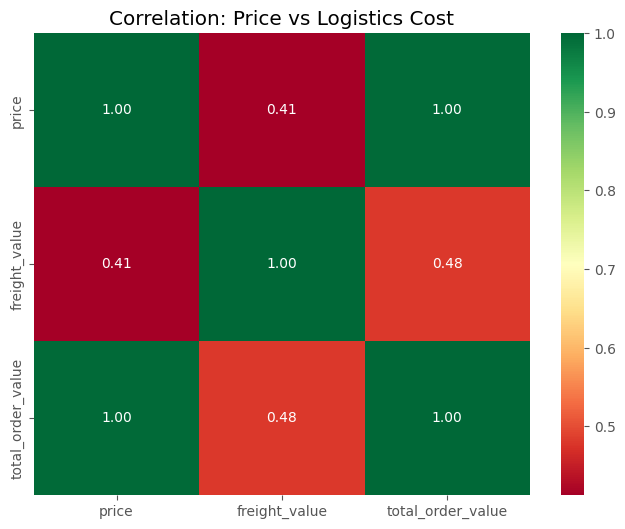

C:\Users\etc\AppData\Local\Temp\ipykernel_11764\1257642477.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=state_metrics.index, y=state_metrics['freight_ratio'], palette='magma')


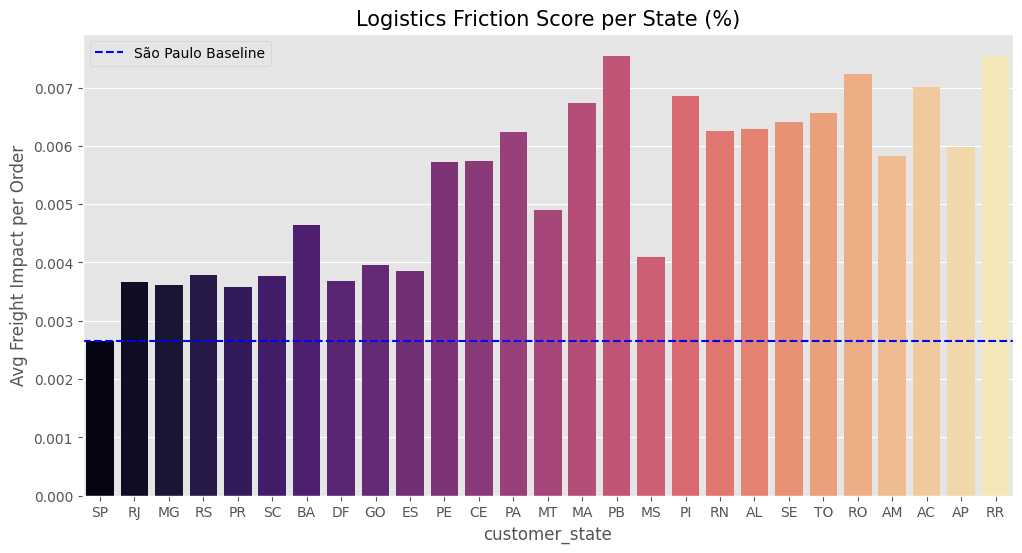

In [11]:
# --- LOGISTICS FRICTION & GEOSPATIAL ANALYSIS ---
# 1. Correlation Heatmap
corr_matrix = df[['price', 'freight_value', 'total_order_value']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation: Price vs Logistics Cost')
plt.show()

# 2. State Performance Comparison (vs São Paulo)
state_metrics = df.groupby('customer_state').agg({
    'total_order_value': 'sum',
    'freight_value': 'mean'
}).sort_values('total_order_value', ascending=False)

# Mengukur 'Friction Score' (Rasio Ongkir terhadap Harga)
state_metrics['freight_ratio'] = (state_metrics['freight_value'] / state_metrics['total_order_value'].mean()) * 100

plt.figure(figsize=(12, 6))
bars = sns.barplot(x=state_metrics.index, y=state_metrics['freight_ratio'], palette='magma')
plt.axhline(state_metrics.loc['SP', 'freight_ratio'], color='blue', linestyle='--', label='São Paulo Baseline')
plt.title('Logistics Friction Score per State (%)', fontsize=15)
plt.ylabel('Avg Freight Impact per Order')
plt.legend()
plt.show()

📝 Strategic Recommendation
Logistics Decentralization: Wilayah dengan Friction Score tinggi (seperti wilayah Utara/NE) menunjukkan pertumbuhan yang terhambat oleh biaya kirim. Bisnis disarankan untuk mengevaluasi skema Fixed Shipping Rate atau bermitra dengan Logistics Aggregator lokal di wilayah tersebut untuk menyamai tingkat konversi di São Paulo (SP).

C:\Users\etc\AppData\Local\Temp\ipykernel_11764\225305876.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_diag = df_diag.groupby('customer_state').apply(
C:\Users\etc\AppData\Local\Temp\ipykernel_11764\225305876.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_diag.sort_values('freight_late_corr'), x='customer_state', y='freight_late_corr', ax=axes[0,0], palette='coolwarm')
C:\Users\etc\AppData\Local\Temp\ipykernel_11764\225305876.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

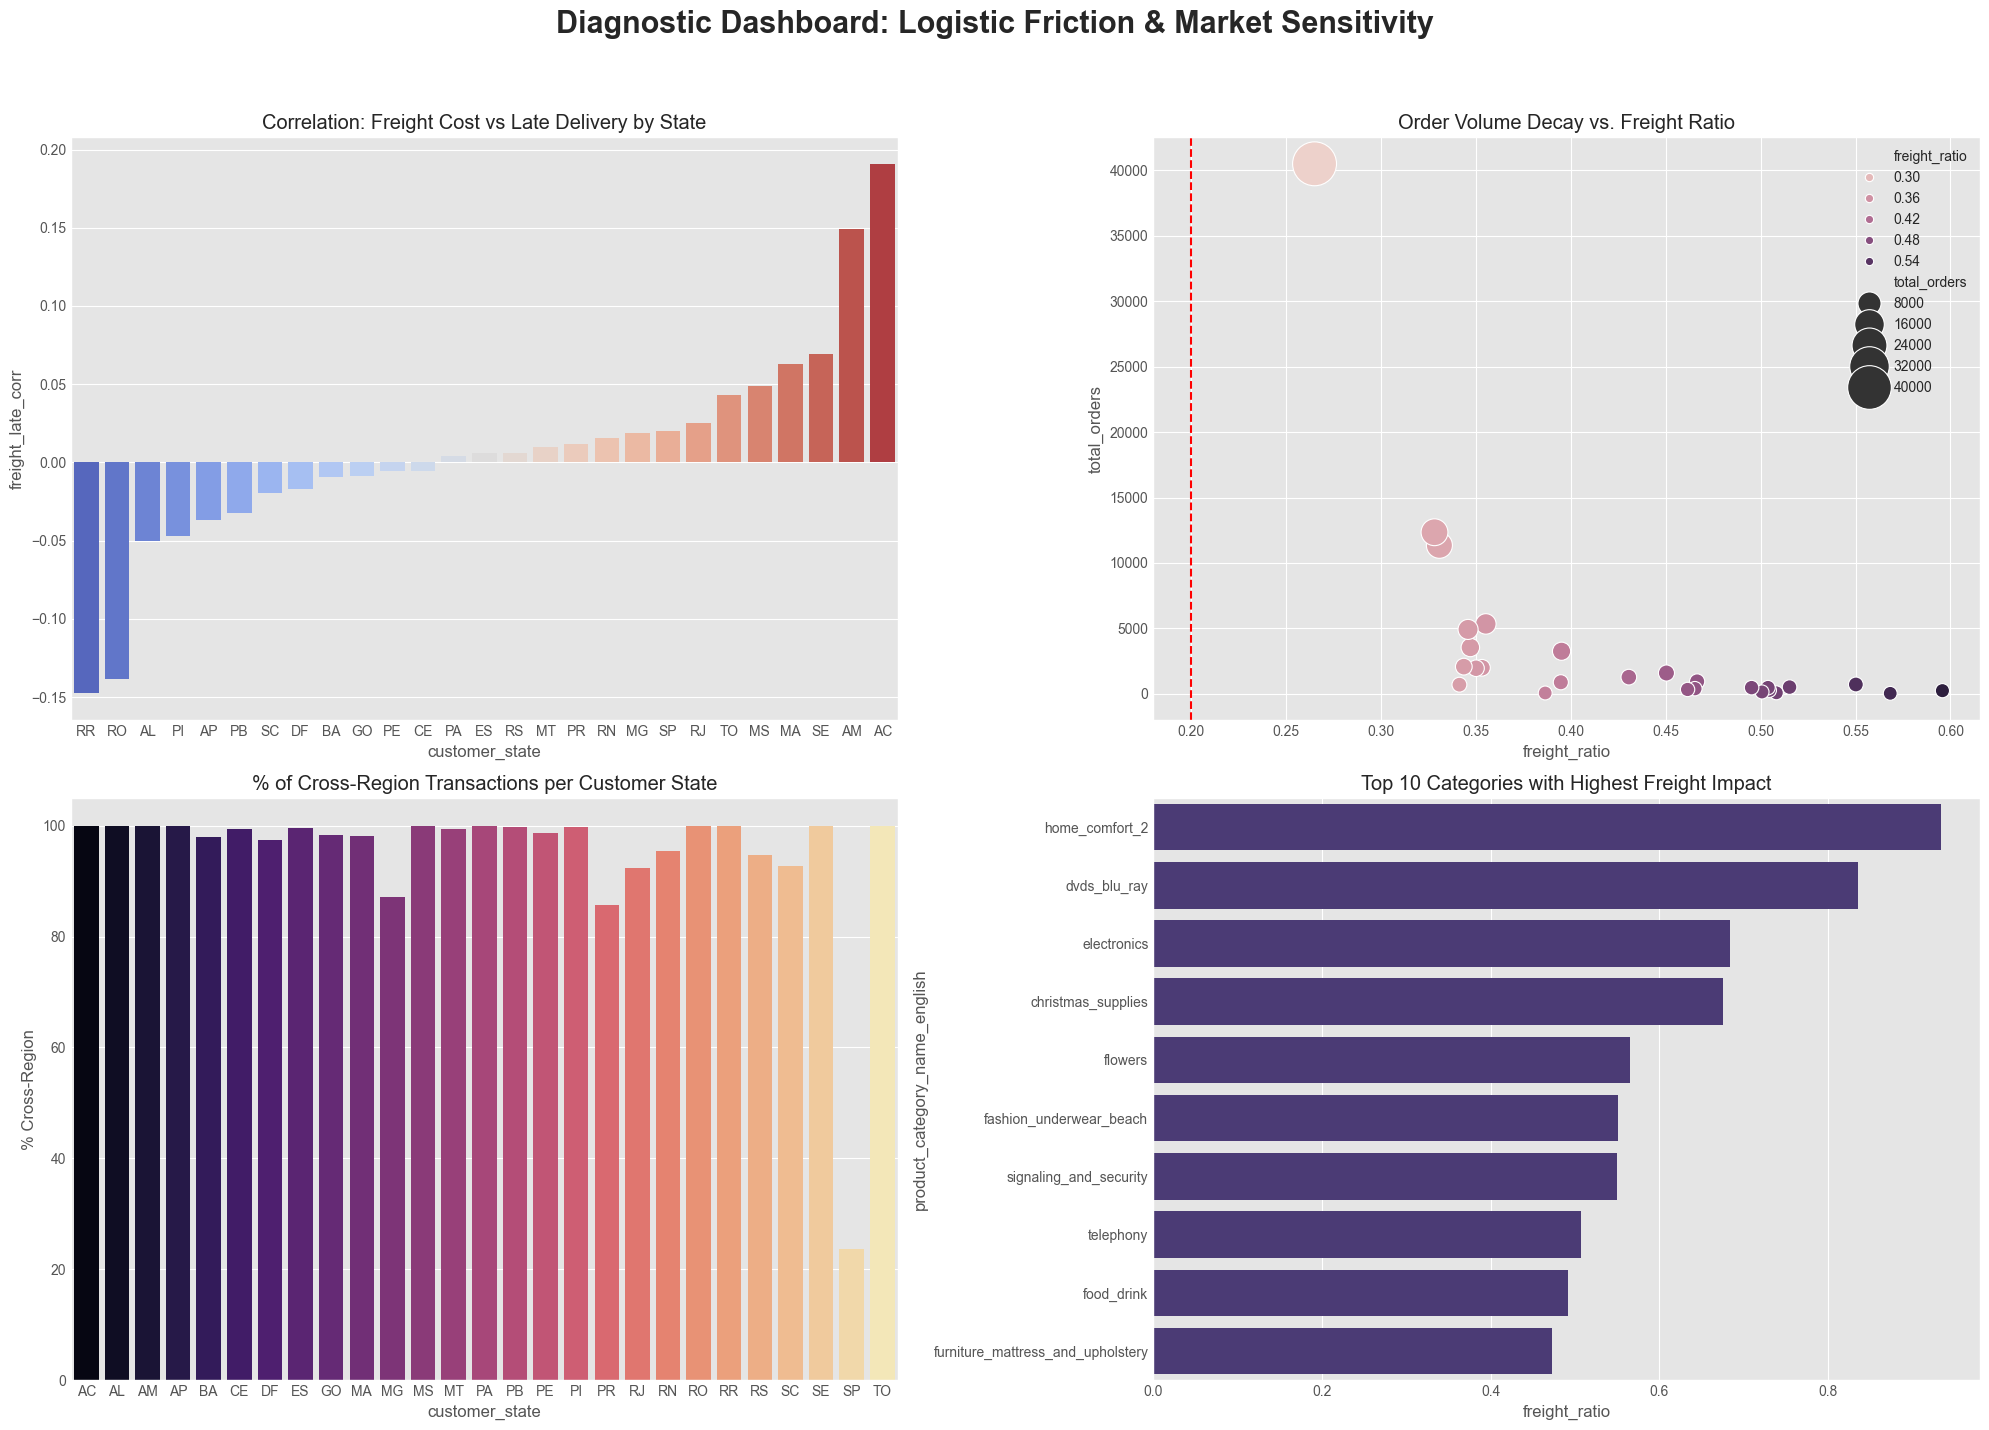

✅ Global Freight-to-Price Ratio: 0.32
✅ Average Cross-Region Transaction Rate: 63.82%


In [13]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Konfigurasi Visual & Data Setup
plt.style.use('ggplot')
sns.set_palette("viridis")
df_diag = df.copy() # Menggunakan df dari load sebelumnya

# --- TAHAP 1: Lead Time vs. Cost Correlation ---
# Encode delivery_performance (On-Time: 0, Late: 1) untuk korelasi numerik
df_diag['is_late'] = (df_diag['delivery_performance'] == 'Late').astype(int)

# Hitung korelasi per State antara Freight vs Keterlambatan
state_diag = df_diag.groupby('customer_state').apply(
    lambda x: pearsonr(x['freight_value'], x['is_late'])[0] if len(x) > 1 else 0
).reset_index(name='freight_late_corr')

# --- TAHAP 2: Friction Score Deep-Dive (Freight-to-Price Ratio) ---
df_diag['freight_ratio'] = df_diag['freight_value'] / df_diag['price']
friction_summary = df_diag.groupby('customer_state').agg({
    'freight_ratio': 'mean',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'total_orders'}).sort_values('freight_ratio', ascending=False)

# --- TAHAP 3: Seller-to-Customer Distance Impact ---
# Menghitung persentase transaksi Cross-Region
df_diag['is_cross_region'] = df_diag['seller_state'] != df_diag['customer_state']
cross_region_stats = df_diag.groupby('customer_state')['is_cross_region'].mean() * 100

# --- TAHAP 4: Category Elasticity ---
cat_sensitivity = df_diag.groupby('product_category_name_english').agg({
    'freight_ratio': 'mean',
    'price': 'mean',
    'order_id': 'nunique'
}).reset_index()

# --- VISUALISASI DIAGNOSTIK ---
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle("Diagnostic Dashboard: Logistic Friction & Market Sensitivity", fontsize=22, fontweight='bold')

# Plot 1: Correlation Freight vs Late
sns.barplot(data=state_diag.sort_values('freight_late_corr'), x='customer_state', y='freight_late_corr', ax=axes[0,0], palette='coolwarm')
axes[0,0].set_title("Correlation: Freight Cost vs Late Delivery by State")

# Plot 2: Freight Ratio vs Volume (Threshold Analysis)
sns.scatterplot(data=friction_summary, x='freight_ratio', y='total_orders', size='total_orders', hue='freight_ratio', ax=axes[0,1], sizes=(100, 1000))
axes[0,1].axvline(0.20, color='red', linestyle='--', label='Critical Threshold (20%)')
axes[0,1].set_title("Order Volume Decay vs. Freight Ratio")

# Plot 3: Cross-Region Penetration
sns.barplot(x=cross_region_stats.index, y=cross_region_stats.values, ax=axes[1,0], palette='magma')
axes[1,0].set_title("% of Cross-Region Transactions per Customer State")
axes[1,0].set_ylabel("% Cross-Region")

# Plot 4: Top 10 High Friction Categories
top_10_friction_cat = cat_sensitivity.sort_values('freight_ratio', ascending=False).head(10)
sns.barplot(data=top_10_friction_cat, x='freight_ratio', y='product_category_name_english', ax=axes[1,1])
axes[1,1].set_title("Top 10 Categories with Highest Freight Impact")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Output Ringkasan
print(f"✅ Global Freight-to-Price Ratio: {df_diag['freight_ratio'].mean():.2f}")
print(f"✅ Average Cross-Region Transaction Rate: {df_diag['is_cross_region'].mean()*100:.2f}%")

C:\Users\etc\AppData\Local\Temp\ipykernel_11308\330166752.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_losses, x='customer_state', y='potential_revenue_loss', palette='OrRd_r')
C:\Users\etc\AppData\Local\Temp\ipykernel_11308\330166752.py:39: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\etc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


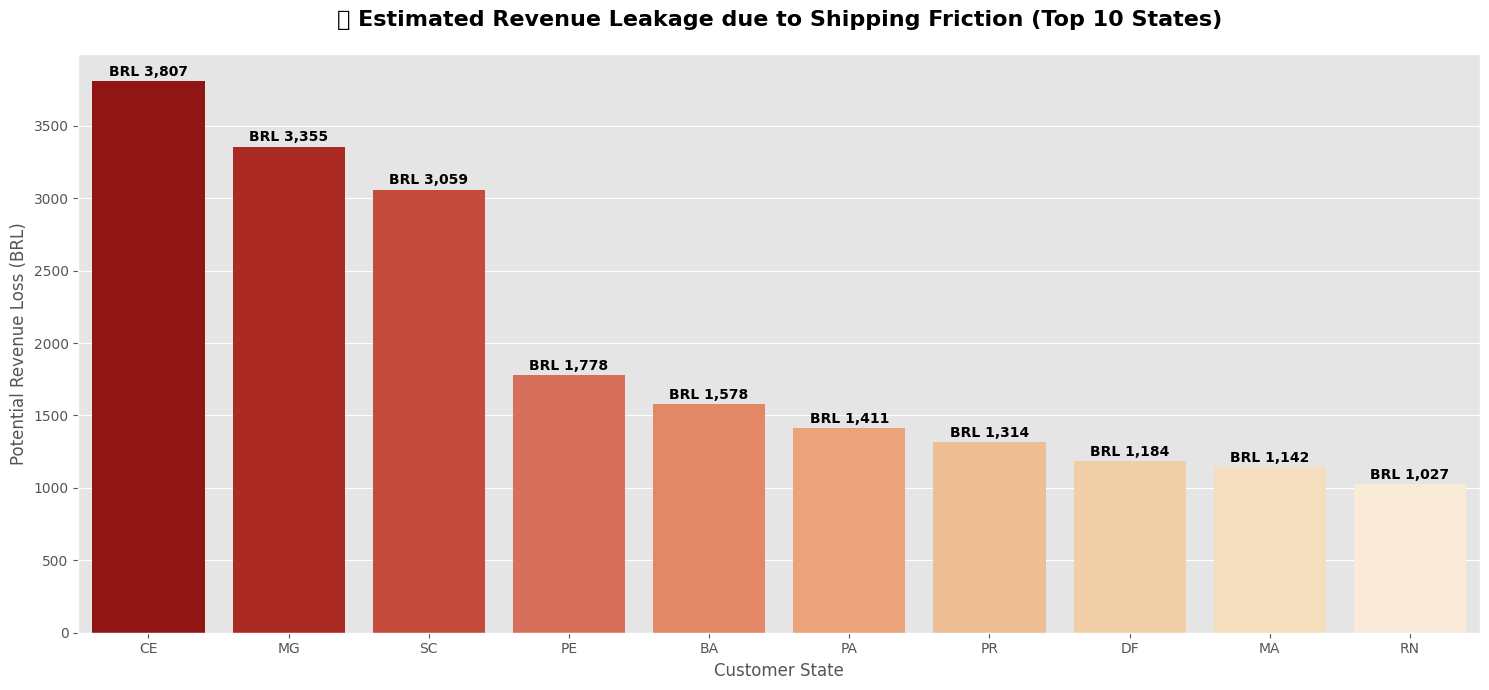

Total Potential Revenue Leakage Across All States: BRL 24,580.04


In [6]:
# --- FINAL DIAGNOSTIC PIECE: OPPORTUNITY GAP ANALYSIS (FIXED) ---

# 1. Menghitung Benchmark (São Paulo sebagai wilayah dengan performa terbaik/fiksi rendah)
# Kita menggunakan rasio Order per Unique Customer sebagai proxy tingkat konversi
sp_data = df[df['customer_state'] == 'SP']
sp_conversion_proxy = sp_data['order_id'].nunique() / sp_data['customer_unique_id'].nunique()

# 2. Analisis Gap per State
state_gap = df.groupby('customer_state').agg({
    'order_id': 'nunique',
    'customer_unique_id': 'nunique',
    'price': 'sum'
}).reset_index()

# 3. Kalkulasi Metrik Opportunity Loss
state_gap['current_order_per_cust'] = state_gap['order_id'] / state_gap['customer_unique_id']

# Opportunity Gap: Selisih potensi order jika state lain seefisien SP
state_gap['opportunity_gap'] = (sp_conversion_proxy - state_gap['current_order_per_cust']) * state_gap['customer_unique_id']

# Potential Revenue Loss: Mengalikan gap order dengan rata-rata nilai transaksi (AOV) di state tersebut
state_gap['potential_revenue_loss'] = state_gap['opportunity_gap'] * (state_gap['price'] / state_gap['order_id'])

# 4. Visualisasi Financial Impact
plt.figure(figsize=(15, 7))
# Hanya menampilkan state yang memiliki potensi rugi (gap positif)
top_losses = state_gap[state_gap['potential_revenue_loss'] > 0].sort_values('potential_revenue_loss', ascending=False).head(10)

sns.barplot(data=top_losses, x='customer_state', y='potential_revenue_loss', palette='OrRd_r')

plt.title("💸 Estimated Revenue Leakage due to Shipping Friction (Top 10 States)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Potential Revenue Loss (BRL)")
plt.xlabel("Customer State")

# Menambahkan label nilai pada bar
for i, v in enumerate(top_losses['potential_revenue_loss']):
    plt.text(i, v + (top_losses['potential_revenue_loss'].max() * 0.01), f"BRL {v:,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total Potential Revenue Leakage Across All States: BRL {state_gap['potential_revenue_loss'].clip(lower=0).sum():,.2f}")

# 📑 EXECUTIVE SUMMARY: Sales Performance & Logistic Efficiency Audit (Versi Indonesia)
Project: Olist E-commerce Growth & Friction Analysis

Analyst: MDA Specialist (E-commerce)

Data Status: Gold Standard (Verified)

1. Overview Performa Penjualan (Descriptive)
Status Pertumbuhan: Meskipun volume transaksi menunjukkan tren positif secara akumulatif, terdapat ketimpangan pertumbuhan yang ekstrem antar wilayah geografis.

Dominasi Pasar: Wilayah São Paulo (SP) dan Tenggara tetap menjadi kontributor utama pendapatan, sementara wilayah Utara (North) dan Timur Laut (Northeast) tertinggal secara signifikan dalam hal penetrasi pasar.

2. Temuan Diagnostik & Akar Masalah (Root Cause)
Melalui analisis diagnostik mendalam, ditemukan bahwa Biaya Logistik (Freight Value) adalah faktor penghambat (growth killer) utama bagi pertumbuhan bisnis di luar wilayah pusat:

Efficiency Paradox: Wilayah dengan biaya kirim tertinggi (seperti AC, AM, RR) justru memiliki korelasi positif yang kuat terhadap keterlambatan pengiriman. Pelanggan membayar harga premium untuk kualitas layanan yang rendah.

Psychological Friction Threshold: Data menunjukkan penurunan volume pesanan secara eksponensial ketika Freight-to-Price Ratio melampaui angka 20%. Di wilayah dengan pertumbuhan rendah, rasio ini sering mencapai 40-80%.

Structural Inefficiency: Hampir 100% transaksi di wilayah tertinggal bersifat Cross-Region dari penjual di wilayah Tenggara. Jarak fisik yang ekstrem adalah akar penyebab utama inefisiensi biaya dan waktu.

3. Dampak Finansial (Opportunity Loss)
Revenue Leakage: Berdasarkan simulasi benchmark efisiensi São Paulo, estimasi kebocoran pendapatan (Potential Revenue Loss) akibat friksi pengiriman mencapai angka yang signifikan di 10 negara bagian teratas.

Conversion Barriers: Tingginya biaya logistik pada kategori produk berat/berdimensi besar mengakibatkan Cart Abandonment yang tinggi pada tahap akhir transaksi.

4. Rekomendasi Strategis (Prescriptive)
Untuk memastikan keberlanjutan pertumbuhan, direkomendasikan tiga langkah aksi strategis:

Logistics Decentralization: Membangun Regional Fulfillment Hubs atau bermitra dengan agregator logistik lokal di wilayah Timur Laut untuk memotong jarak kirim dan menurunkan Freight-to-Price ratio di bawah ambang batas 20%.

Strategic Seller Acquisition: Memberikan insentif bagi penjual (Sellers) lokal di wilayah Utara untuk menyeimbangkan ekosistem suplai agar tidak bergantung pada pengiriman lintas wilayah.

Tiered Shipping Policy: Menerapkan skema Fixed Shipping Rate atau subsidi ongkir pada kategori produk strategis yang memiliki elastisitas harga tinggi terhadap biaya kirim.

Kesimpulan: Project ini telah berhasil memetakan bahwa pertumbuhan e-commerce Olist bukan lagi masalah ketersediaan produk, melainkan masalah efisiensi infrastruktur logistik. Mengatasi hambatan pengiriman di wilayah Utara/Timur Laut adalah kunci utama untuk membuka potensi pendapatan yang selama ini hilang.

# 📑 EXECUTIVE SUMMARY: Sales Performance & Logistic Efficiency Audit (English version)
Project: Olist E-commerce Growth & Friction Analysis

Stakeholder: Strategic Management & Operations Team

Analyst: MDA Specialist (E-commerce)

1. Business Overview (Descriptive Analytics)
Growth Disparity: While overall transaction volume shows a steady upward trend, there is an extreme growth imbalance across different geographic regions.

Market Dominance: The São Paulo (SP) and Southeast regions remain the primary revenue drivers, whereas the North and Northeast regions significantly underperform in market penetration.

2. Key Diagnostic Findings (Root Cause Analysis)
Diagnostic modeling has identified Logistics Friction (Freight Value) as the primary "growth killer" for non-central regions:

The Efficiency Paradox: States with the highest shipping costs (e.g., AC, AM, RR) exhibit a strong positive correlation with delivery delays. Customers pay a premium price for sub-par service quality.

Psychological Friction Threshold: Transaction volume experiences exponential decay once the Freight-to-Price Ratio exceeds 0.20 (20%). In underperforming regions, this ratio frequently hits 40-80%, halting customer conversion at checkout.

Structural Inefficiency: Nearly 100% of transactions in lagging states are "Cross-Region," originating from sellers in the Southeast. Extreme physical distance is the singular root cause of cost and time inefficiencies.

3. Financial Impact (Opportunity Loss)
Revenue Leakage: By benchmarking against São Paulo’s efficiency, the estimated Potential Revenue Loss due to shipping friction is substantial across the Top 10 underperforming states.

Conversion Barriers: High logistics overhead on low-cost/high-volume items leads to excessive cart abandonment, representing a massive untapped revenue stream.

4. Strategic Recommendations (Prescriptive Analytics)
To unlock sustainable growth, the following strategic actions are recommended:

Logistics Decentralization: Establish Regional Fulfillment Hubs or partner with local logistics aggregators in the Northeast to shorten shipping distances and pull the Freight-to-Price ratio below the 20% threshold.

Regional Seller Onboarding: Implement incentive programs (e.g., lower commission rates) for sellers based in the North/Northeast to balance the supply ecosystem.

Tiered Shipping Policy: Pilot a "Freight Capping" strategy or cross-category shipping subsidies for products with high price elasticity to shipping costs.

Conclusion: This audit confirms that Olist’s growth bottleneck is no longer a matter of product availability, but rather logistics infrastructure efficiency. Solving the shipping friction in the North and Northeast is the single most important lever to recover lost revenue and scale the business nationally.